In [95]:
import cv2
import mediapipe as mp
import numpy as np
import imutils
from matplotlib import pyplot as plt

In [96]:
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

ballCoord = []

rightAnkle = []
leftAnkle = []

rightKnee = []
leftKnee =[]

calc_timestamps = [0.0]

result = "The move is correct"

bally = 0
ballx = 0

In [99]:
cap = cv2.VideoCapture('redBallDakdak1.mp4')
#cap = cv2.VideoCapture(0)

fps = cap.get(cv2.CAP_PROP_FPS)

timestamps = [cap.get(cv2.CAP_PROP_POS_MSEC)]

## Setup mediapipe instance
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    try:
        while cap.isOpened():
            ret, frame = cap.read()
            
            frame = imutils.resize(frame, width=350)
            
            frame = imutils.rotate_bound(frame, 180)
            # Recolor image to RGB
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False
        
            # Make detection
            results = pose.process(image)
            
            #Detect the ball by the color blue

            img_HSV = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

#             BLUE_MIN = np.array([100,88,0],np.uint8)
#             BLUE_MAX = np.array([141,255,255],np.uint8)
            
            RED_MIN = np.array([138,76,83],np.uint8)
            RED_MAX = np.array([180,255,255],np.uint8)
            
            frame_threshed = cv2.inRange(img_HSV, RED_MIN, RED_MAX)
            
            # Find contours
            cnts = cv2.findContours(frame_threshed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[-2]  # Use index [-2] to be compatible to OpenCV 3 and 4

            # Draw rectangle around the ball
            for c in cnts:
                x, y, w, h = cv2.boundingRect(c)
                if (w*h) < 10000 and (w*h) > 1300:
                    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), thickness = 2)
                    bally  = y + h
                    ballx = x

            # Recolor back to BGR
            image.flags.writeable = True
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
            
            # Extract landmarks
            try:
                landmarks = results.pose_landmarks.landmark
                #print(landmarks)
                timestamps.append(cap.get(cv2.CAP_PROP_POS_MSEC))
                calc_timestamps.append(calc_timestamps[-1] + 1000/fps)

                rightAnkle.append([landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x,landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y])
                leftAnkle.append([landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x,landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y])

                rightKnee.append([landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x,landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y])
                leftKnee.append([landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y])
                
                ballCoord.append([ballx , bally])

                # get the size of the frame
                h, w, c = image.shape

                # Get the location of the knee
                kneex = (landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x) * w
                kneey = (landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y) * h

                # Check if the ball in the correct position comparing to the knee
                if(bally > kneey and kneex - 70 > ballx ) :
                    result = "The move is incorrect"
                    
                font = cv2.FONT_HERSHEY_SIMPLEX
                place = (int(w*0.1),int(h*0.1))
                fontScale = 0.8
                fontColor = (0,255,0)
                thickness = 2
                lineType  = 2
                
                if(result == "The move is incorrect" ):
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    place = (int(w*0.1),int(h*0.1))
                    fontScale = 0.8
                    fontColor = (0,0,255)
                    thickness = 2
                    lineType  = 2

                cv2.putText(image,result, 
                    place, 
                    font, 
                    fontScale,
                    fontColor,
                    thickness,
                    lineType)
                
            except:
                pass
            
            
            # Render detections
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                    mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2), 
                                    mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2) 
                                    )               
            
            cv2.imshow('Detection', image)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

    except:
        pass
    cv2.waitKey(0)
    cap.release()
    cv2.destroyAllWindows()

    print(result)



The move is correct


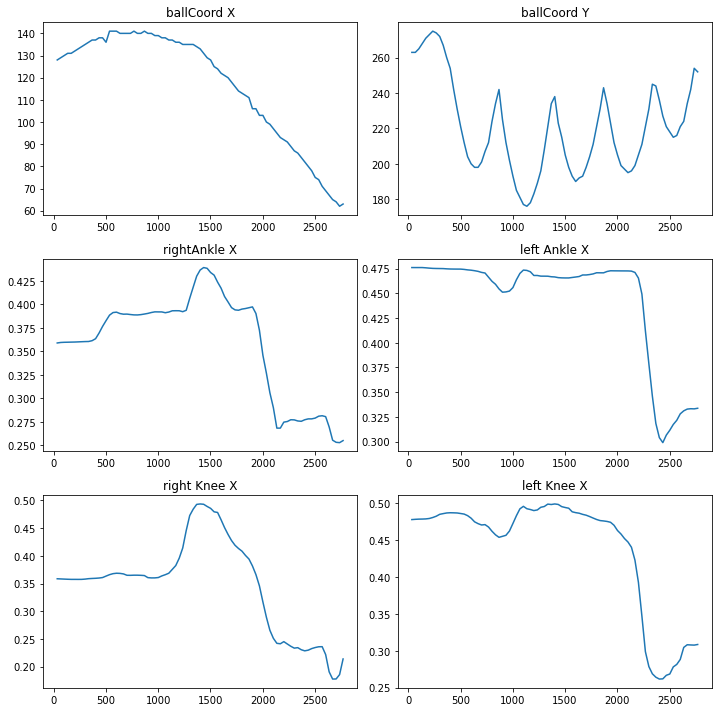

In [79]:
X = calc_timestamps[1:]

Y1 = [x[0] for x in ballCoord]

Y3 = [x[1] for x in ballCoord]

Y5 = [x[0] for x in rightAnkle]

Y7 = [x[0] for x in leftAnkle]

Y9 = [x[0] for x in rightKnee]

Y11 = [x[0] for x in leftKnee]

# Initialise the subplot function using number of rows and columns
figure, axis = plt.subplots(3,2,figsize=(10, 10))

  
axis[0, 0].plot(X, Y1)
axis[0, 0].set_title("ballCoord X")

axis[0, 1].plot(X, Y3)
axis[0, 1].set_title("ballCoord Y")

axis[1, 0].plot(X, Y5)
axis[1, 0].set_title("rightAnkle X")

axis[1, 1].plot(X, Y7)
axis[1, 1].set_title("left Ankle X")

axis[2, 0].plot(X, Y9)
axis[2, 0].set_title("right Knee X")

axis[2, 1].plot(X, Y11)
axis[2, 1].set_title("left Knee X")


plt.tight_layout()

# Combine all the operations and display
plt.show()

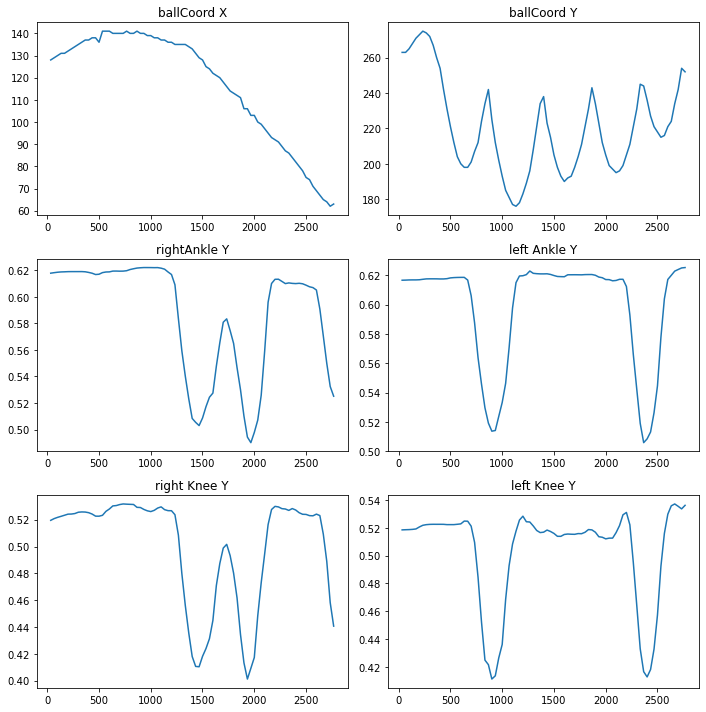

In [80]:
X = calc_timestamps[1:]

Y1 = [x[0] for x in ballCoord]

Y3 = [x[1] for x in ballCoord]

Y5 = [x[1] for x in rightAnkle]

Y7 = [x[1] for x in leftAnkle]

Y9 = [x[1] for x in rightKnee]

Y11 = [x[1] for x in leftKnee]

# Initialise the subplot function using number of rows and columns
figure, axis = plt.subplots(3,2,figsize=(10, 10))

  
axis[0, 0].plot(X, Y1)
axis[0, 0].set_title("ballCoord X")

axis[0, 1].plot(X, Y3)
axis[0, 1].set_title("ballCoord Y")

axis[1, 0].plot(X, Y5)
axis[1, 0].set_title("rightAnkle Y")

axis[1, 1].plot(X, Y7)
axis[1, 1].set_title("left Ankle Y")

axis[2, 0].plot(X, Y9)
axis[2, 0].set_title("right Knee Y")

axis[2, 1].plot(X, Y11)
axis[2, 1].set_title("left Knee Y")


plt.tight_layout()

# Combine all the operations and display
plt.show()